In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive/sales-data-analysis-project/data')

['Sample - Superstore.csv']

#Load the Dataset into Pandas

In [ ]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/sales-data-analysis-project/data/Sample - Superstore.csv',
    encoding='latin1'
)

#View the First 5 Rows of the Dataset


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#Inspect Dataset Structure

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

#Check Missing Values

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


#Check for Duplicate Rows

In [ ]:
df.duplicated().sum()

np.int64(0)

#Convert Date Columns to Datetime Format

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

In [ ]:
df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


#Create Year and Month Columns

In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

In [ ]:
df[['Order Date', 'Year', 'Month']].head()

,Order Date,Year,Month
0,2016-11-08,2016,November
1,2016-11-08,2016,November
2,2016-06-12,2016,June
3,2015-10-11,2015,October
4,2015-10-11,2015,October


#Create Profit Margin Column

In [ ]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

In [ ]:
df[['Sales', 'Profit', 'Profit Margin']].head()

,Sales,Profit,Profit Margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


#Find the Top-Selling Product Categories

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


#First Sales Visualization

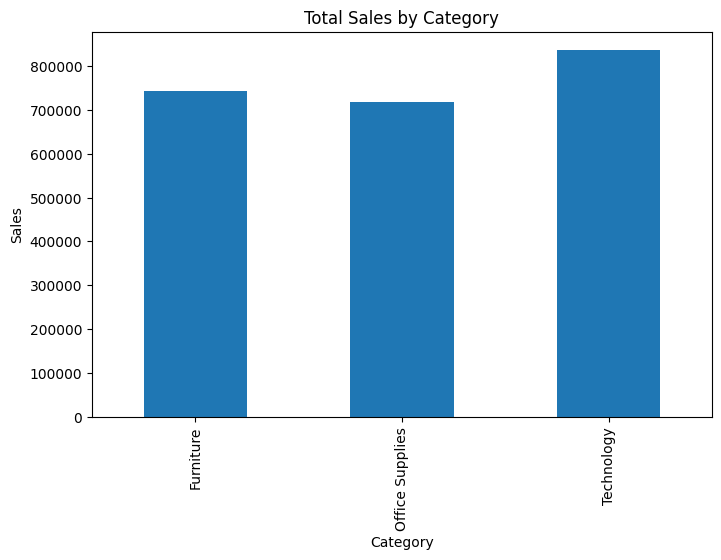

In [ ]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar', figsize=(8,5))

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()

#Analyze Sales by Region

In [ ]:
regional_sales = df.groupby('Region')['Sales'].sum()

regional_sales

,Sales
Region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


#Visualize Regional Sales

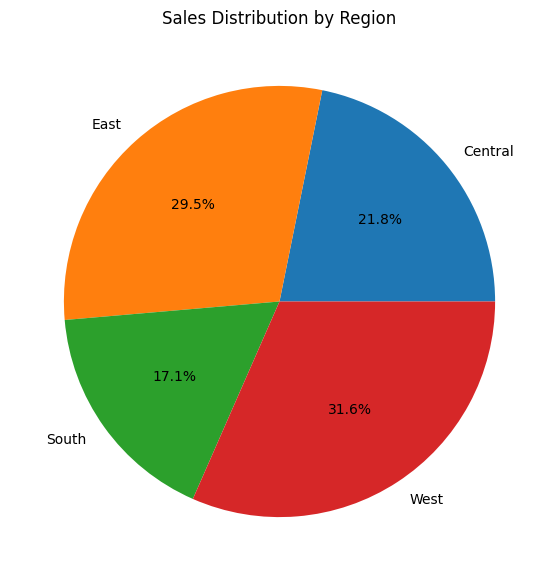

In [ ]:
regional_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))

plt.title('Sales Distribution by Region')
plt.ylabel('')

plt.show()

#Analyze Monthly Sales Trends

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales

,Sales
Month,
April,137762.1286
August,159044.0630
December,325293.5035
February,59751.2514
January,94924.8356
July,147238.0970
June,152718.6793
March,205005.4888
May,155028.8117


#Fix Month Order for Proper Time-Series Analysis

In [ ]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_sales = monthly_sales.reindex(month_order)

monthly_sales

,Sales
Month,
January,94924.8356
February,59751.2514
March,205005.4888
April,137762.1286
May,155028.8117
June,152718.6793
July,147238.0970
August,159044.0630
September,307649.9457


#Create Monthly Sales Trend Line Chart

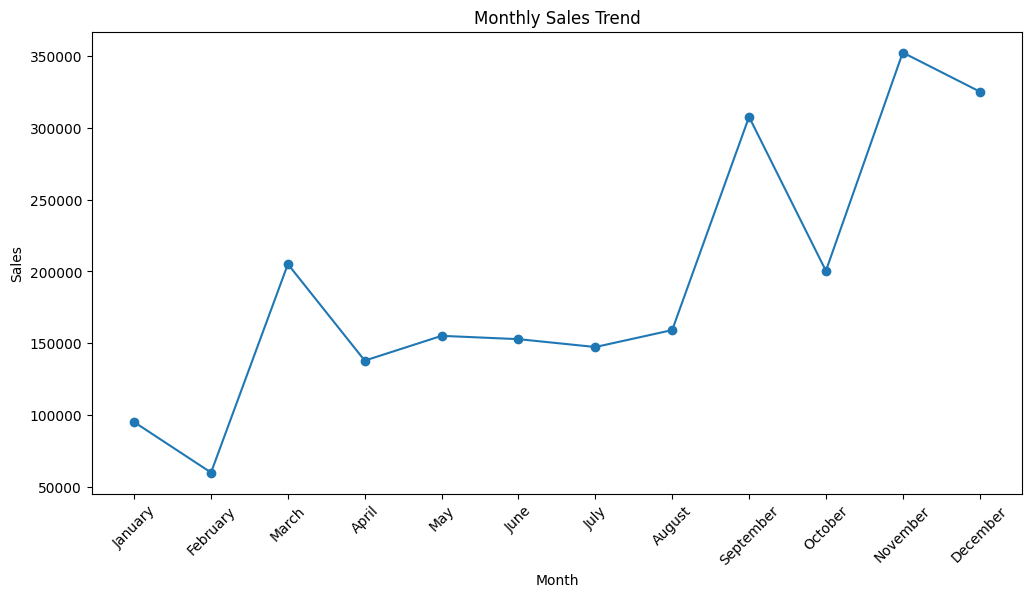

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.show()

#Find Top-Selling Sub-Categories

In [ ]:
top_subcategories = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

top_subcategories.head(10)

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


#Visualize Top 10 Sub-Categories

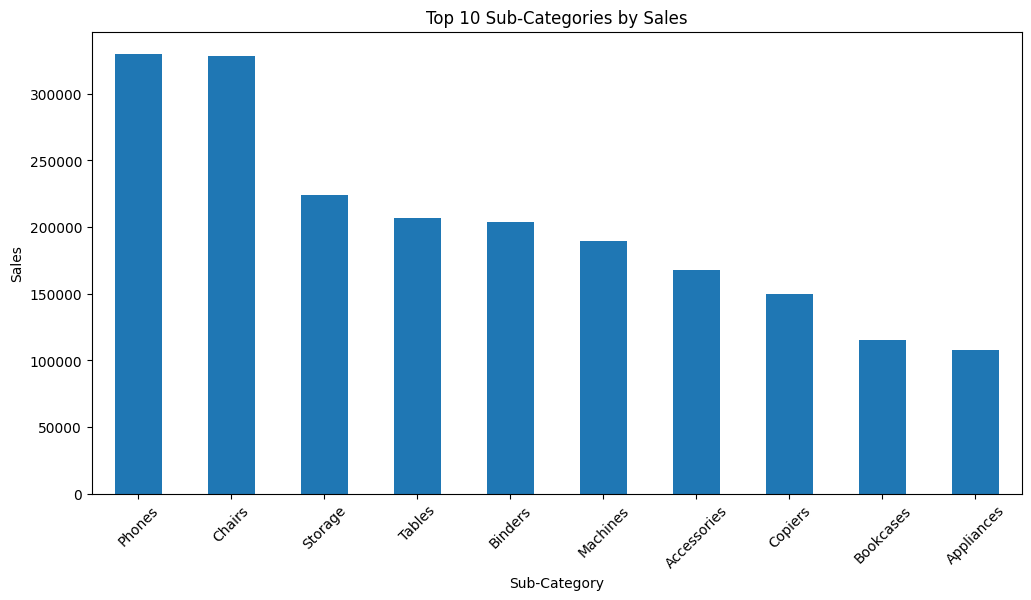

In [ ]:
plt.figure(figsize=(12,6))

top_subcategories.head(10).plot(kind='bar')

plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.show()

#Analyze Most Profitable and Least Profitable Categories

In [ ]:
category_profit = df.groupby('Category')['Profit'].sum()

category_profit

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


#Visualize Category Profit Analysis

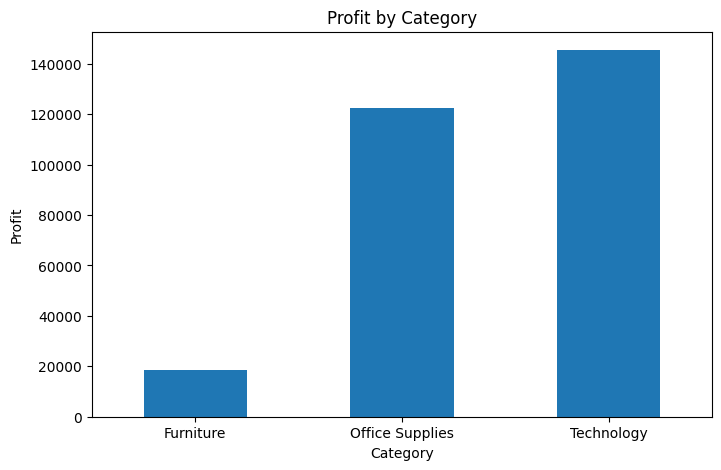

In [ ]:
plt.figure(figsize=(8,5))

category_profit.plot(kind='bar')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')

plt.xticks(rotation=0)

plt.show()

#Find Loss-Making Sub-Categories

In [ ]:
subcat_profit = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values()
)

subcat_profit

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.2540
Art,6527.7870
Envelopes,6964.1767
Furnishings,13059.1436


#Visualize Profit and Loss by Sub-Category

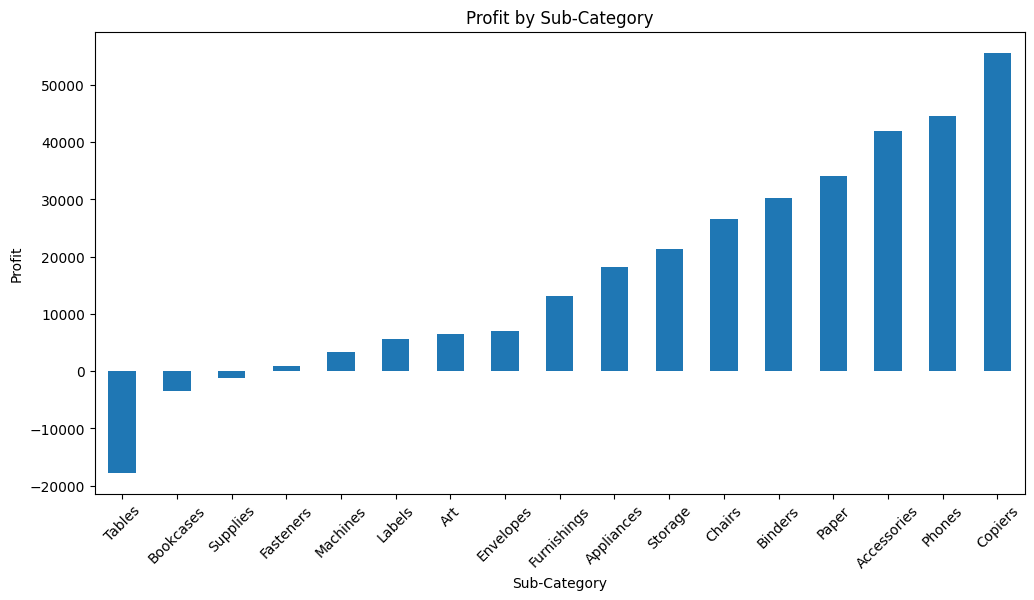

In [ ]:
plt.figure(figsize=(12,6))

subcat_profit.plot(kind='bar')

plt.title('Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')

plt.xticks(rotation=45)

plt.show()

#Analyze the Relationship Between Discount and Profit

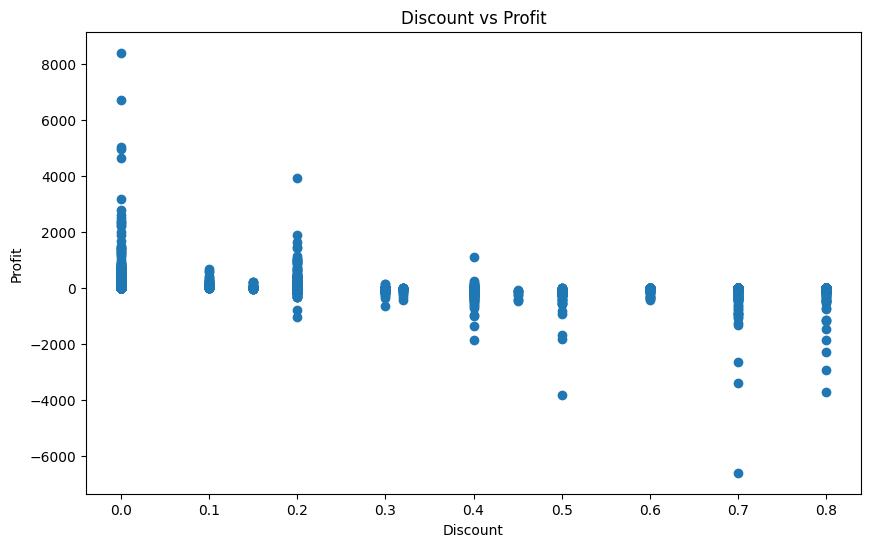

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(df['Discount'], df['Profit'])

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

In [ ]:
df.to_csv(
    '/content/drive/MyDrive/sales-data-analysis-project/data/cleaned_sales_data.csv',
    index=False
)

In [ ]:
import os

os.listdir('/content/drive/MyDrive/sales-data-analysis-project/data')

['Sample - Superstore.csv', 'cleaned_sales_data.csv']